# Economic Indicators and Inflation Project

## Introduction

* Economic performance influences nearly every aspect of local and national planning, from employment and investment to public service demand and infrastructure development. This project explores the relationship between key macroeconomic indicators — including GDP, inflation, unemployment, and economic growth — across four major economies: the United Kingdom, the United States, Germany, and France, between 2010 and 2025.

## Method

* Using indexed GDP analysis and comparative economic indicators, the project aims to identify long-term growth trends, periods of economic disruption, and signs of economic resilience. Particular attention is given to how economies responded to major shocks such as the COVID-19 pandemic and subsequent inflationary pressures. 

## Purpose

* Through a combination of data cleaning, transformation, and visual analysis using Python and pandas, this project demonstrates how data storytelling can be used to communicate complex economic trends in a clear and accessible way. The findings provide insight into how macroeconomic conditions evolve and how data-driven analysis can support strategic thinking within public sector organisations.





---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [15]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\rayaf\\Documents\\Macro_analysis'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [16]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [17]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\rayaf\\Documents'

# Section 1

Section 1 content

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---

In [19]:
macro_data = pd.read_csv(r"C:\Users\rayaf\Documents\Macro_analysis\data\cleaned_data\macro_data.csv")
macro_data.head()

,Country,Year,GDP (in billion USD),Inflation Rate (%),Unemployment Rate (%),Economic Growth (%),GDP_Index
0,France,2010,2400.0,1.5,9.5,1.7,100.0
1,France,2011,2500.0,2.3,9.8,1.1,104.2
2,France,2012,2600.0,2.0,10.0,0.0,108.3
3,France,2013,2700.0,0.9,10.3,-0.2,112.5
4,France,2014,2800.0,0.3,10.5,0.2,116.7


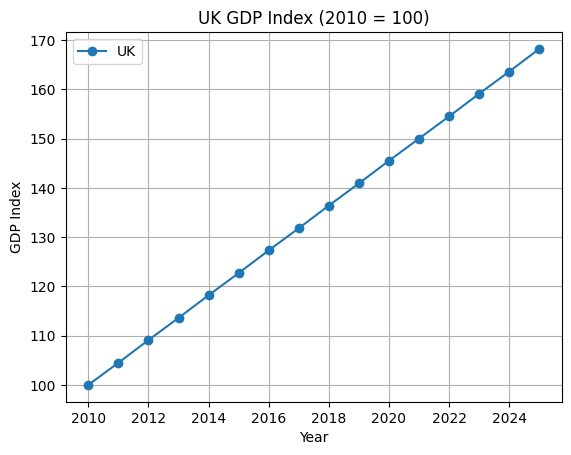

In [20]:
# Filter for UK data
uk_data = macro_data[macro_data['Country'] == 'UK']

# Plot GDP Index
plt.plot(
    uk_data['Year'],
    uk_data['GDP_Index'],
    marker='o',
    label='UK'
)

# Labels and formatting
plt.title("UK GDP Index (2010 = 100)")
plt.xlabel("Year")
plt.ylabel("GDP Index")

plt.legend()
plt.grid(True)

plt.show()


### Between 2010 and 2025, the UK economy expanded substantially, with indexed GDP rising by more than 68%. Despite periods of economic disruption, including the 2020 downturn, the long-term trajectory remained consistently upward. This raises an important question for local authorities: what economic conditions supported this resilience, and how might they influence future regional planning and investment decisions?

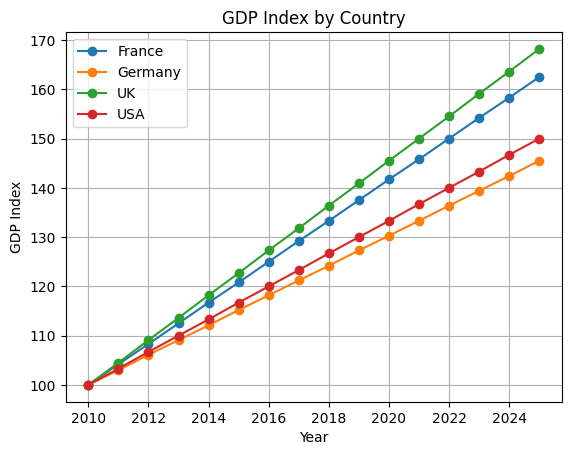

In [21]:
countries = macro_data['Country'].unique() # Get unique country names

for c in countries:
    subset = macro_data[macro_data['Country'] == c]
    plt.plot(subset['Year'], subset['GDP_Index'], marker='o', label=c)

plt.title("GDP Index by Country")
plt.xlabel("Year")
plt.ylabel("GDP Index")
plt.legend()
plt.grid(True)
plt.show()


### When we compare GDP Index values from 2010 to 2025, we’re looking at how quickly each economy has grown relative to its own 2010 baseline; this is not the absolute size of the economy.

### The UK shows the strongest relative growth over this period, indicating that its GDP expanded more rapidly than the other countries in the dataset relative to its 2010 level. France and the USA follow a similar trajectory but with more moderate cumulative growth, while Germany shows the slowest relative expansion.

### This pattern highlights differences in long‑term economic momentum rather than economic scale. The UK’s higher index suggests stronger cumulative growth, whereas Germany’s flatter profile points to more subdued long‑term expansion. These differences may reflect structural factors such as productivity trends, investment levels, labour market dynamics, and exposure to global shocks


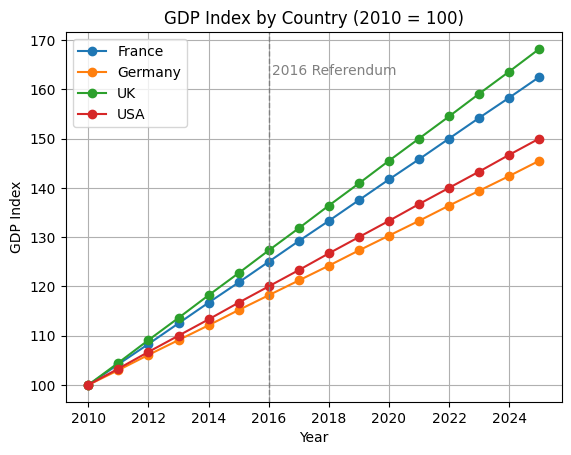

In [22]:
countries = macro_data['Country'].unique() # Get unique country names

for c in countries:
    subset = macro_data[macro_data['Country'] == c]
    plt.plot(subset['Year'], subset['GDP_Index'], marker='o', label=c)

# Add a vertical line at 2016 to mark the divergence point
plt.axvline(x=2016, color='grey', linestyle='--', linewidth=1)
plt.text(2016 + 0.1, plt.ylim()[1] * 0.95, "2016 Referendum", color='grey')

plt.title("GDP Index by Country (2010 = 100)")
plt.xlabel("Year")
plt.ylabel("GDP Index")
plt.legend()
plt.grid(True)
plt.show()


### From 2010 to 2016, the GDP Index trends for the UK, France, Germany, and the USA move broadly in parallel. After the 2016 referendum, the UK’s growth path begins to flatten relative to its earlier momentum, while France and the USA maintain steadier cumulative growth. Germany continues to grow but at the slowest rate overall.

### The vertical line marks the point where this divergence begins, highlighting how the UK’s relative growth slows compared with its pre‑2016 trend. Since the GDP Index measures growth relative to each country’s own 2010 baseline, the chart reflects differences in economic momentum rather than economic size.

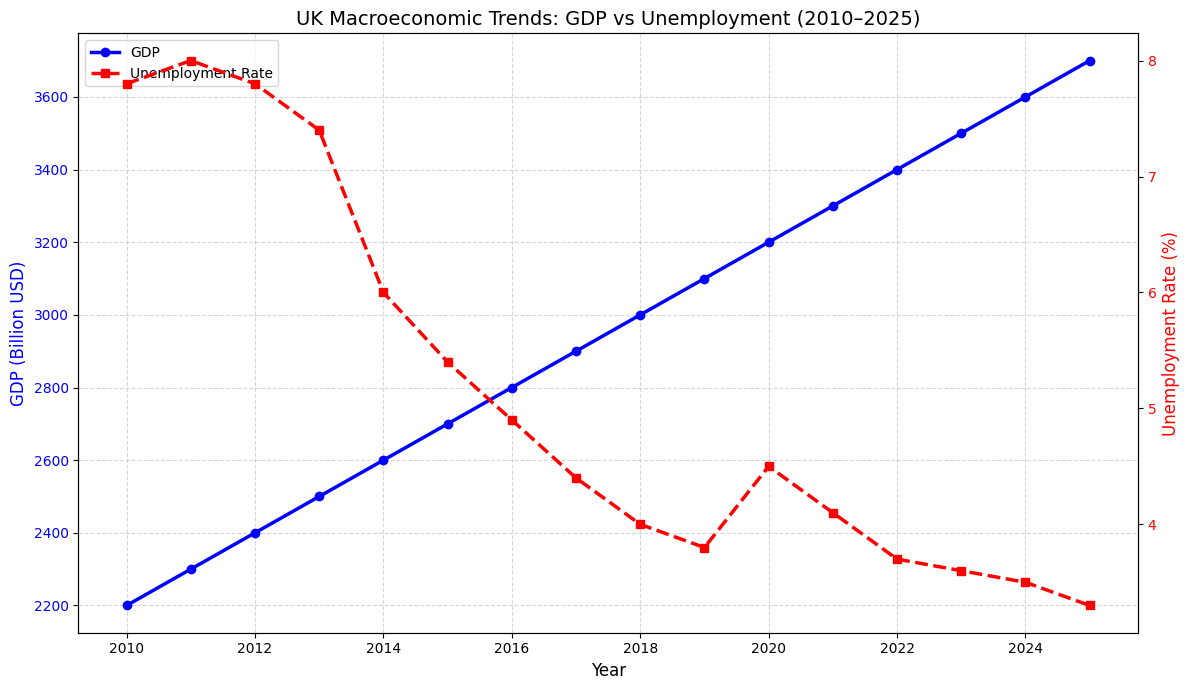

In [23]:


# Filter data for the UK
uk_data = macro_data[macro_data['Country'] == 'UK']

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 7))

# GDP plot
color_gdp = 'blue'

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('GDP (Billion USD)', color=color_gdp, fontsize=12)

line1 = ax1.plot(
    uk_data['Year'],
    uk_data['GDP (in billion USD)'],
    color=color_gdp,
    marker='o',
    linewidth=2.5,
    label='GDP'
)

ax1.tick_params(axis='y', labelcolor=color_gdp)

# Secondary axis for unemployment
ax2 = ax1.twinx()

color_unemp = 'red'

line2 = ax2.plot(
    uk_data['Year'],
    uk_data['Unemployment Rate (%)'],
    color=color_unemp,
    linestyle='--',
    marker='s',
    linewidth=2.5,
    label='Unemployment Rate'
)

ax2.set_ylabel('Unemployment Rate (%)', color=color_unemp, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_unemp)

# Title and grid
plt.title('UK Macroeconomic Trends: GDP vs Unemployment (2010–2025)', fontsize=14)

ax1.grid(True, linestyle='--', alpha=0.5)

# Combine legends
lines = line1 + line2
labels = [line.get_label() for line in lines]

ax1.legend(lines, labels, loc='upper left')

# Display chart
plt.tight_layout()
plt.show()

## As UK GDP Recovered After the Recession, Unemployment Gradually Declined
### This chart highlights a clear inverse pattern between GDP and unemployment in the UK. As GDP strengthens, unemployment consistently moves lower, showing how improvements in economic output translate into better labour‑market conditions. The dual‑axis view helps reveal this relationship at a glance, turning two separate indicators into a single, cohesive story about the UK’s economic momentum.

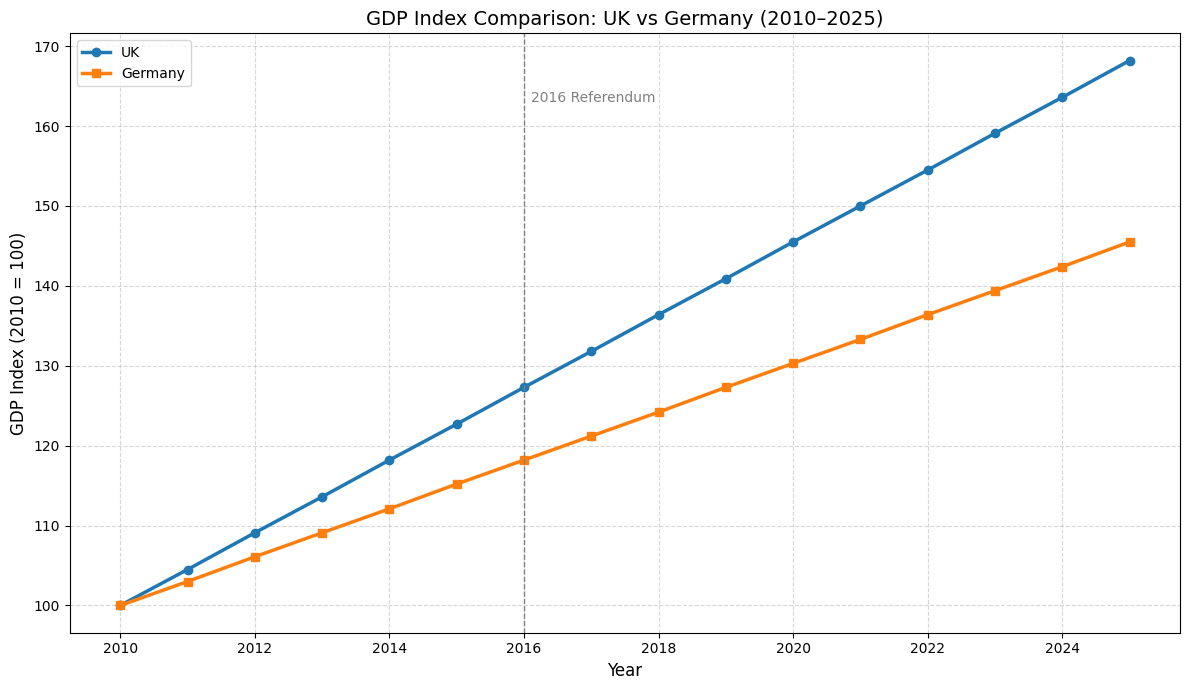

In [24]:


# Filter for UK and Germany
uk_data = macro_data[macro_data['Country'] == 'UK']
ger_data = macro_data[macro_data['Country'] == 'Germany']

plt.figure(figsize=(12, 7))

# Plot UK
plt.plot(
    uk_data['Year'],
    uk_data['GDP_Index'],
    marker='o',
    linewidth=2.5,
    label='UK'
)

# Plot Germany
plt.plot(
    ger_data['Year'],
    ger_data['GDP_Index'],
    marker='s',
    linewidth=2.5,
    label='Germany'
)

# Add 2016 reference line
plt.axvline(x=2016, color='grey', linestyle='--', linewidth=1)
plt.text(2016 + 0.1, plt.ylim()[1] * 0.95, "2016 Referendum", color='grey')

# Labels and formatting
plt.title("GDP Index Comparison: UK vs Germany (2010–2025)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("GDP Index (2010 = 100)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()


### The comparison shows that both economies follow similar growth paths up to 2016. After the referendum, the UK’s GDP Index begins to flatten relative to its earlier trend, while Germany continues on a slower but steadier path. Since the GDP Index measures growth relative to each country’s 2010 baseline, the chart highlights differences in economic momentum rather than economic size.

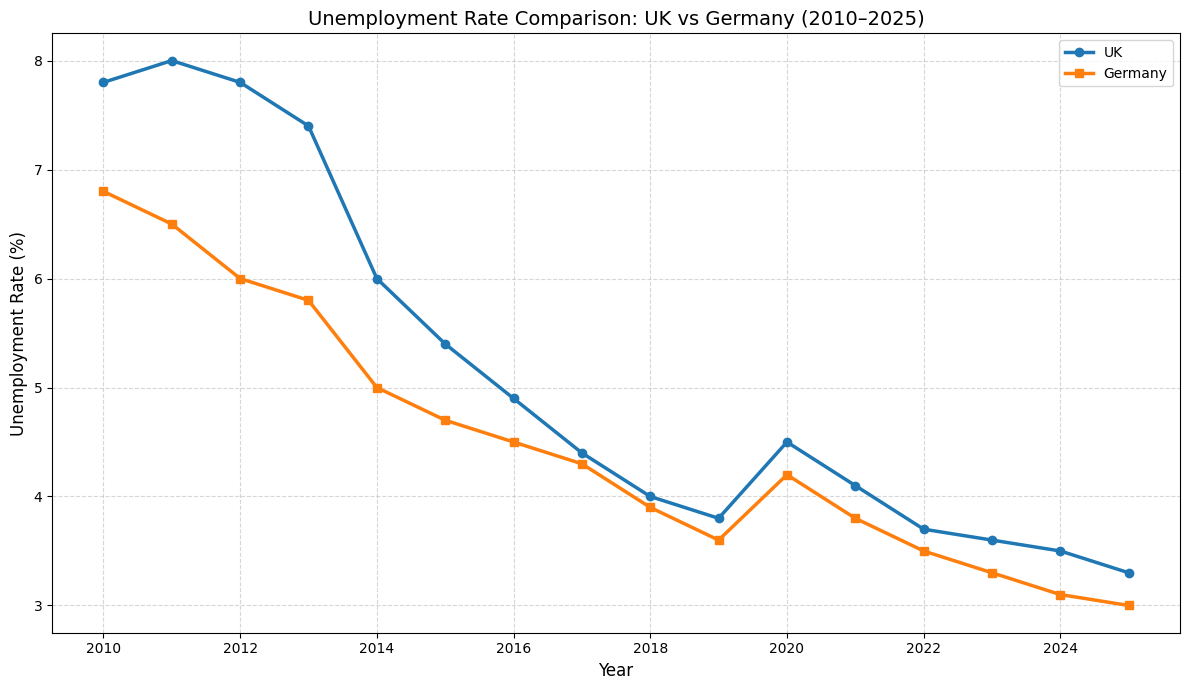

In [25]:


# Filter for UK and Germany
uk_data = macro_data[macro_data['Country'] == 'UK']
ger_data = macro_data[macro_data['Country'] == 'Germany']

plt.figure(figsize=(12, 7))

# Plot UK unemployment
plt.plot(
    uk_data['Year'],
    uk_data['Unemployment Rate (%)'],
    marker='o',
    linewidth=2.5,
    label='UK'
)

# Plot Germany unemployment
plt.plot(
    ger_data['Year'],
    ger_data['Unemployment Rate (%)'],
    marker='s',
    linewidth=2.5,
    label='Germany'
)

plt.title("Unemployment Rate Comparison: UK vs Germany (2010–2025)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Unemployment Rate (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()


### The unemployment comparison highlights a consistent gap between Germany and the UK from 2010 to 2025, with Germany maintaining lower and more stable unemployment throughout. This resilience aligns with Germany’s strong vocational training system and its large, skills‑intensive industrial base, which help anchor workers in stable employment even during economic shocks.

### For the UK, the contrast underscores how investment in human capital can strengthen economic performance. Workforce training and skills development — areas where local authorities can play a direct role — are key levers for improving productivity, supporting businesses, and ultimately boosting long‑term GDP growth. The chart turns this into a clear takeaway: economies with stronger skills pipelines tend to experience lower unemployment and more durable growth momentum.

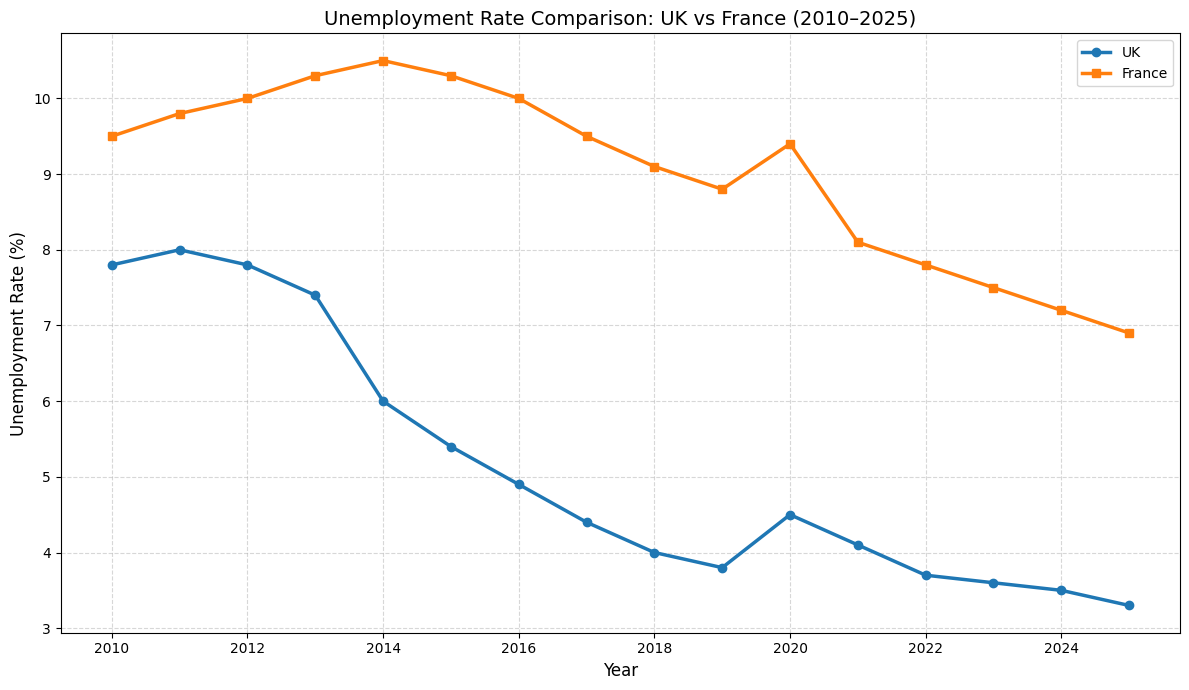

In [26]:


# Filter for UK and France
uk_data = macro_data[macro_data['Country'] == 'UK']
fr_data = macro_data[macro_data['Country'] == 'France']

plt.figure(figsize=(12, 7))

# Plot UK unemployment
plt.plot(
    uk_data['Year'],
    uk_data['Unemployment Rate (%)'],
    marker='o',
    linewidth=2.5,
    label='UK'
)

# Plot France unemployment
plt.plot(
    fr_data['Year'],
    fr_data['Unemployment Rate (%)'],
    marker='s',
    linewidth=2.5,
    label='France'
)

plt.title("Unemployment Rate Comparison: UK vs France (2010–2025)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Unemployment Rate (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()


### The unemployment comparison highlights how France’s more structured vocational pathways and stronger industrial base support more stable labour‑market outcomes than the UK. While both economies face similar macroeconomic shocks, France maintains lower and less volatile unemployment, reflecting the resilience created by coordinated skills development. The contrast reinforces a broader theme: economies with stronger training systems and deeper technical sectors tend to experience more stable employment and more durable growth momentum.

## Takeaway
### Cities like Coventry and Swindon show how a strong skills base attracts and anchors major employers — from Peugeot to Honda — and how workforce capability becomes a competitive advantage. As the economy shifts toward AI, automation, and green technologies, the same principle applies: regions with the right training pipelines will capture the next wave of investment.

C:\Users\rayaf\AppData\Local\Temp\ipykernel_18492\3323623696.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=volatility, x='Country', y='Economic Growth (%)', palette=colors)


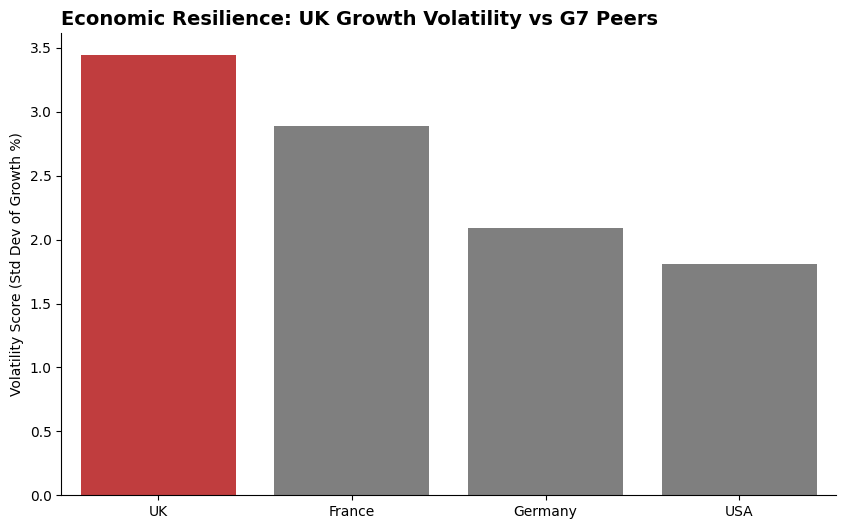

In [31]:
# Ensure numeric types (The 'Cleaning' Narrative)
cols_to_fix = ['Economic Growth (%)', 'Inflation Rate (%)', 'Unemployment Rate (%)']
for col in cols_to_fix:
    macro_data[col] = pd.to_numeric(macro_data[col], errors='coerce')

# Calculate Volatility
volatility = (
    macro_data.groupby('Country')['Economic Growth (%)']
    .std()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))
colors = ['#d62728' if c == 'UK' else '#7f7f7f' for c in volatility['Country']]
sns.barplot(data=volatility, x='Country', y='Economic Growth (%)', palette=colors)

plt.title('Economic Resilience: UK Growth Volatility vs G7 Peers', loc='left', fontsize=14, fontweight='bold')
plt.ylabel('Volatility Score (Std Dev of Growth %)')
plt.xlabel('')
sns.despine()
plt.show()


### The comparison between countries shows that the UK experiences more fluctuations in its economic growth than its G7 counterparts. This reflects an economic environment that is less predictable. So, when it comes to long-term planning, it makes it harder for businesses and investors. Those countries with a stronger industrial base and skills infrastructure can maintain their momentum and absorb the shocks more effectively. This is where local authorities have a role in supporting businesses.


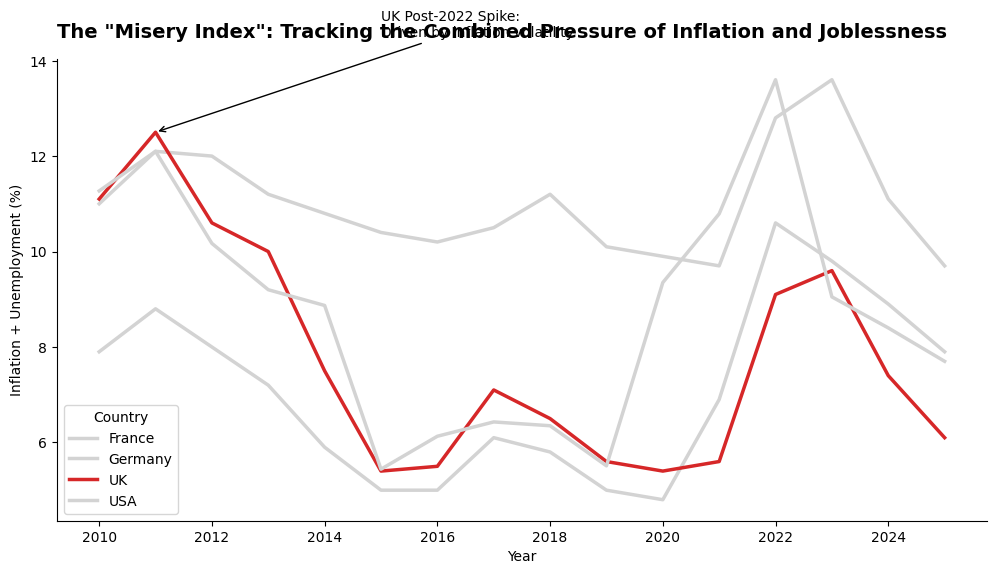

In [32]:
# Create the metric using the correct column names
macro_data['misery_index'] = (
    macro_data['Inflation Rate (%)'] + macro_data['Unemployment Rate (%)']
)

plt.figure(figsize=(12, 6))

# Define colours for the story
palette = {c: "lightgrey" for c in macro_data['Country'].unique()}
palette['UK'] = "#d62728"

sns.lineplot(
    data=macro_data,
    x='Year',
    y='misery_index',
    hue='Country',
    palette=palette,
    linewidth=2.5
)

plt.title(
    'The "Misery Index": Tracking the Combined Pressure of Inflation and Joblessness',
    loc='left',
    fontsize=14,
    fontweight='bold',
    pad=15
)
plt.ylabel('Inflation + Unemployment (%)')

# Add a Dykes-style annotation
uk_subset = macro_data[macro_data['Country'] == 'UK']
peak_year = uk_subset.loc[uk_subset['misery_index'].idxmax(), 'Year']
peak_value = uk_subset['misery_index'].max()

plt.annotate(
    'UK Post-2022 Spike:\nDriven by inflation volatility',
    xy=(peak_year, peak_value),
    xytext=(2015, peak_value + 2),
    arrowprops=dict(arrowstyle='->', color='black')
)

sns.despine()
plt.show()


### The misery index above highlights how the UK experienced a sharp rise in combined inflation and unemployment after 2022, driven primarily by inflation volatility. While other countries also faced price pressures, the UK’s spike stands out, underscoring how inflation shocks can amplify economic stress when labour market resilience is weaker. The chart turns two separate indicators into a single, intuitive measure of household pressure.

### So, this  put pressure on local authorities in terms of spending to support the unemployed through training for new AI skills, green technologies and families through the cost of living crisis.

# Section 2

Section 2 content

---

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [27]:
import os

try:
    os.makedirs("data/raw", exist_ok=True)
except Exception as e:
    print(e)
